## 05 - Analysis

In this notebook, we aim at exploring a bit the results we obtained from all the experiments that have been run so far.

We have ran a lot of experiments for a set amount of epochs, enough to basically converge, for both KANs and MLPs. We will focus on the following aspects:
- Compare the Approximate Mean Significance (AMS), Area Under the Curve (AUC), Accuracy and Binary Cross Entropy (BCE) of both models with regards to the number of neurons
- Compare the same metrics with regards to the number of parameters.
- Analyze the convergence speed of both models, to see if one of them tends to converge faster than the other. Both in terms of epochs and wall-clock time.

We will have to bear in mind that, because we trained for a fixed number of epochs, some models might not have fully converged yet. This is especially true for some of the KANs, which seem to converge following some weird patterns (Possibly they are more prone to falling into local minima?). For that reason, we will look at the rate of change of the metrics over the last few epochs, to get an idea of whether they have converged or not.


### Data Loading
Because we didn't log the results into a CSV or anything, and instead used MLflow, we will have to load all the data from it into a DataFrame with all the results we need.

> **IMPORTANT:** Before running the code, we have to make sure that the MLflow tracking URI environment variable is set to point to the right location where the experiments were logged.
> We'll do so by loading an env file that have to contain that variable. So **make sure to create a `.env` file right next to this notebook with the following**
> ```
> MLFLOW_TRACKING_URI="https://<username>:<password>@mlflow.parcerisa.xyz"
> ```

In [1]:
import dotenv

loaded = dotenv.load_dotenv(".env")  # Load environment variables from .env file
if not loaded:
    raise RuntimeError("Failed to load .env file. Please create one with the required environment variables.")

In [74]:
import mlflow
import pandas as pd

MLP_EXPERIMENT_NAME = "MLP Higgs Experiment"
KAN_EXPERIMENT_NAME = "KAN Higgs Experiment"

mlp_experiment = mlflow.get_experiment_by_name(MLP_EXPERIMENT_NAME)
if not mlp_experiment:
    raise ValueError(f"Experiment '{MLP_EXPERIMENT_NAME}' not found in MLflow.")
kan_experiment = mlflow.get_experiment_by_name(KAN_EXPERIMENT_NAME)
if not kan_experiment:
    raise ValueError(f"Experiment '{KAN_EXPERIMENT_NAME}' not found in MLflow.")

mlp_runs = mlflow.search_runs(experiment_ids=[mlp_experiment.experiment_id])
kan_runs = mlflow.search_runs(experiment_ids=[kan_experiment.experiment_id])

if not isinstance(mlp_runs, pd.DataFrame) or mlp_runs.empty:
    raise ValueError(f"No runs found for experiment '{MLP_EXPERIMENT_NAME}'.")
if not isinstance(kan_runs, pd.DataFrame) or kan_runs.empty:
    raise ValueError(f"No runs found for experiment '{KAN_EXPERIMENT_NAME}'.")

mlp_runs = mlp_runs[mlp_runs["status"] == "FINISHED"]
kan_runs = kan_runs[kan_runs["status"] == "FINISHED"]

print(f"MLP Experiment '{MLP_EXPERIMENT_NAME}' has {len(mlp_runs)} runs.")
print(f"KAN Experiment '{KAN_EXPERIMENT_NAME}' has {len(kan_runs)} runs.")

mlp_runs["model_type"] = "MLP"
kan_runs["model_type"] = "KAN"
df = pd.concat([mlp_runs, kan_runs], ignore_index=True)

MLP Experiment 'MLP Higgs Experiment' has 140 runs.
KAN Experiment 'KAN Higgs Experiment' has 141 runs.


These DataFrames contain the "final" results of each experiment, i.e., the results at the last epoch, as well as the hyperparameters used for each experiment. If at some point we need the full history of each experiment, we can always load it from MLflow again.

### Filtering Fully Trained Models

Before we perform any analysis, let us create two new filtered Data Frames that only contain the models that have fully converged. For that, let us obtain the rate of change of AMS, AUC, Accuracy and BCE over the last 5 epochs for all models.

In [75]:
# Before we extract the final metrics, let us explore the available metrics for each run
all_metrics = set()
for run_id in df["run_id"].tolist():
    run = mlflow.get_run(run_id)
    all_metrics.update(run.data.metrics.keys())

print("Available metrics across all runs:")
for metric in sorted(all_metrics):
    print(f"- {metric}")

Available metrics across all runs:
- train_loss_batch
- train_loss_epoch
- val_accuracy_epoch
- val_ams_epoch
- val_auc_epoch
- val_loss_epoch


We are interested only on the validation metrics, specifically:
- val_accuracy_epoch
- val_ams_epoch
- val_auc_epoch
- val_loss_epoch

These have the suffix "_epoch" to indicate that they are logged at the end of each epoch, as opposed to "_batch", which are logged after each batch.

In [7]:
val_metric_names = ["val_accuracy_epoch", "val_ams_epoch", "val_auc_epoch", "val_loss_epoch"]

In [76]:
from collections import defaultdict
from typing import Dict
import pandas as pd
from mlflow.tracking import MlflowClient
from tqdm.auto import tqdm

# To obtain the metric history, we need to go one layer deeper into MLflow
client = MlflowClient()

metric_histories: Dict[str, pd.DataFrame] = {}
for j, run_row in tqdm(df.iterrows(), leave=False, desc=f"Getting histories", total=len(df)):
    data = {}
    max_epoch = 0
    for metric in val_metric_names:
        history = client.get_metric_history(run_row["run_id"], metric)
        data[metric] = pd.DataFrame.from_records(
            [(m.step, m.timestamp, m.value) for m in history], columns=["epoch", "timestamp", metric]
        )
        max_epoch = max(max_epoch, data[metric]["epoch"].max())
    # Now we need to merge all dataframes on epoch
    merged_df = pd.DataFrame({"epoch": range(1, max_epoch + 1), "timestamp": pd.NaT})
    for metric in val_metric_names:
        merged_df = merged_df.merge(data[metric], on="epoch", how="left", suffixes=("", f"_{metric}"))
    # Now average all the available timestamps. This is a bit hacky, but should work fine.
    merged_df["timestamp"] = merged_df[[col for col in merged_df.columns if col.startswith("timestamp")]].mean(axis=1)
    # Finally, drop the extra timestamp columns
    merged_df = merged_df[["epoch", "timestamp"] + val_metric_names]
    metric_histories[run_row["run_id"]] = merged_df

Getting histories:   0%|          | 0/281 [00:00<?, ?it/s]

Now that we have obtained all the histories, we are interested in the slope of the last 5 epochs. To do so, we will simply perform a linear regression over the last 5 points of each metric, and obtain the slope of the fitted line.

In [80]:
from sklearn.linear_model import LinearRegression


def get_slope_of_last_n_epochs(row: pd.Series, metric: str, n: int = 5) -> float:
    """Compute the slope of the last n epochs for a given metric using linear regression."""
    df = metric_histories[row["run_id"]]

    last_n = df.dropna(subset=[metric]).sort_values(by="epoch").tail(n)
    if len(last_n) < 2:
        return float("nan")  # Not enough data to compute slope

    X = last_n["epoch"].values.reshape(-1, 1)
    y = last_n[metric].values

    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0]


filtered_df = df.copy()
for metric in val_metric_names:
    slope_column = f"{metric}_slope"
    filtered_df[slope_column] = filtered_df.apply(lambda row: get_slope_of_last_n_epochs(row, metric), axis=1)

Finally, before manually setting a threshold for convergence, let us first explore the distribution of slopes for both models.

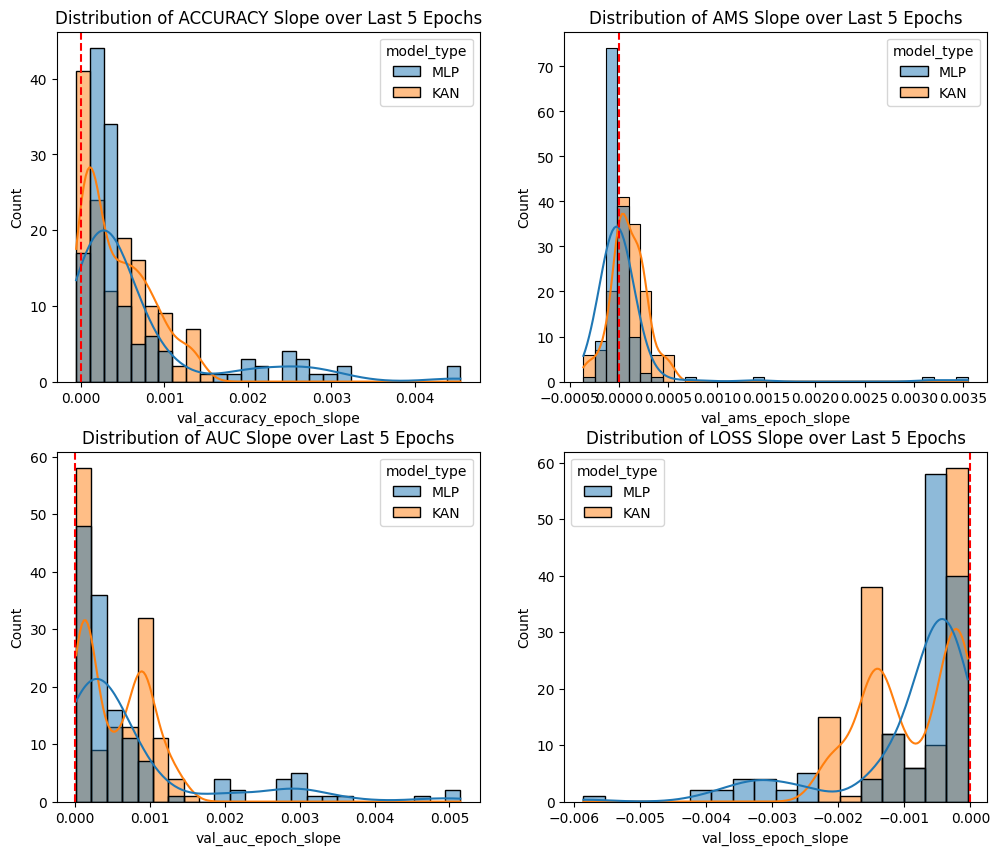

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i, metric in enumerate(val_metric_names):
    r = i // 2
    c = i % 2
    slope_column = f"{metric}_slope"
    sns.histplot(
        data=filtered_df, x=slope_column, fill=True, alpha=0.5, hue="model_type", ax=ax[r, c], color="blue", kde=True
    )
    metric_name = metric.replace("val_", "").replace("_epoch", "").upper()
    ax[r, c].set_title(f"Distribution of {metric_name} Slope over Last 5 Epochs")
    ax[r, c].axvline(0, color="red", linestyle="--", label="Zero Slope")

As expected, most models have slopes close to zero, indicating they converged. However, some models (especially MLPs) didn't quite converge all the way. Also, as expected, for ACCURACY and AUC, the slopes are all positive (we want these metrics to increase over time), while LOSS has all negative slopes (we want the loss to decrease over time). AMS is a bit more mixed, as some models have positive slopes while others have negative ones.

This suggests that models had reached a peak AMS value and then started to fluctuate around it by the end of their trainings.

So, we'll arbitrarily set the following thresholds for convergence:
- |slope| < 0.0015 for ACCURACY.
- |slope| < 0.0005 for AMS.
- |slope| < 0.0015 for AUC.
- |slope| < 0.002 for LOSS.
These threshold seem to separate well the "bulk" of converged models from the long tails of non-converged ones, primarily for MLPs.

We will explore the non-converged models later, because they might provide some insights (we expect those to mostly be MLPs with 1 or 2 neurons on the hidden layer).

In [87]:
thresholds = {
    "val_accuracy_epoch": 0.0015,
    "val_ams_epoch": 0.0005,
    "val_auc_epoch": 0.0015,
    "val_loss_epoch": 0.002,
}
for metric in val_metric_names:
    filtered_df[f"{metric}_is_outlier"] = filtered_df[f"{metric}_slope"].abs() >= thresholds[metric]

# Compute the final is_outlier mask
outlier_columns = [f"{metric}_is_outlier" for metric in val_metric_names]
filtered_df["is_outlier"] = filtered_df[outlier_columns].any(axis=1)

In [88]:
filtered_df[filtered_df["is_outlier"]]

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.val_accuracy_epoch,metrics.train_loss_epoch,metrics.train_loss_batch,metrics.val_loss_epoch,...,params.k,val_accuracy_epoch_slope,val_ams_epoch_slope,val_auc_epoch_slope,val_loss_epoch_slope,val_accuracy_epoch_is_outlier,val_ams_epoch_is_outlier,val_auc_epoch_is_outlier,val_loss_epoch_is_outlier,is_outlier
29,bd7c26f70a10404dbac77e01d44688a7,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-10 13:00:36.158000+00:00,2026-01-10 13:02:43.890000+00:00,0.753921,0.531388,0.527097,0.528724,...,NaN,0.001705,0.000266,0.001889,-0.001442,True,False,True,False,True
90,b500c7837739451d9a6870ab1fd07e06,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 21:22:12.474000+00:00,2026-01-09 21:22:54.344000+00:00,0.754260,0.507574,0.505844,0.504233,...,NaN,0.002723,0.000200,0.002998,-0.003363,True,False,True,True,True
93,11c04dd9bc9b45988f7887c9980cb9b2,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 21:18:13.958000+00:00,2026-01-09 21:18:55.653000+00:00,0.755659,0.506686,0.506497,0.503585,...,NaN,0.002731,0.000051,0.003212,-0.003602,True,False,True,True,True
94,f7b9876fd5fa4480bafc3486857f42c7,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 21:16:30.092000+00:00,2026-01-09 21:17:11.946000+00:00,0.770313,0.484435,0.483276,0.485172,...,NaN,0.001985,0.000102,0.002155,-0.002516,True,False,True,True,True
97,0e00955038d34d8db89b7bc12db78486,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 20:28:27.611000+00:00,2026-01-09 20:29:09.080000+00:00,0.390322,0.720286,0.716982,0.717050,...,NaN,0.000000,0.000000,0.002783,-0.005860,False,False,True,True,True
100,845e15abe3814e56b1923345f783db88,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 19:54:19.081000+00:00,2026-01-09 19:55:02.701000+00:00,0.628965,0.664500,0.663316,0.663269,...,NaN,0.004427,0.003188,0.005146,-0.003976,True,True,True,True,True
101,7ddf2b941e89476d813bdd102417aa8a,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 19:52:28.957000+00:00,2026-01-09 19:53:13.591000+00:00,0.774682,0.480781,0.475357,0.477472,...,NaN,0.001904,0.000079,0.001966,-0.002450,True,False,True,True,True
102,d331ff3f22af4d5ab75f9520ceda633f,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 19:51:40.285000+00:00,2026-01-09 19:52:23.419000+00:00,0.648369,0.637789,0.635389,0.636720,...,NaN,0.003085,0.001391,0.004970,-0.003346,True,True,True,True,True
103,56d3b8e0d545462395b96ce1f8241446,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 19:50:51.824000+00:00,2026-01-09 19:51:34.829000+00:00,0.744687,0.524186,0.518621,0.522353,...,NaN,0.002524,-0.000158,0.002925,-0.003151,True,False,True,True,True
104,896d34ef7baf4daa968718ce452ba963,3,FINISHED,file:///C:/Users/mirxm/Storage/Work/MDS/S3/AML...,2026-01-09 19:50:03.122000+00:00,2026-01-09 19:50:46.559000+00:00,0.750771,0.506402,0.501875,0.508258,...,NaN,0.002730,-0.000024,0.002948,-0.003344,True,False,True,True,True


With these thresholds, we lost 38 rows out of the 281 total we had (~13.5%), which is acceptable.

### AMS as a function of Neurons